### 9. Закрепление знаний
Кейс

Вам представлены данные об оттоке клиентов некоторого банка 

Столбцы таблицы:

1. RowNumber — номер строки таблицы (это лишняя информация, поэтому можете сразу от неё избавиться)
2. CustomerId — идентификатор клиента
3. Surname — фамилия клиента
4. CreditScore — кредитный рейтинг клиента (чем он выше, тем больше клиент брал кредитов и возвращал их)
5. Geography — страна клиента (банк международный)
6. Gender — пол клиента
7. Age — возраст клиента 
8. Tenure — сколько лет клиент пользуется услугами банка
9. Balance — баланс на счетах клиента в банке
10. NumOfProducts — количество услуг банка, которые приобрёл клиент
11. HasCrCard — есть ли у клиента кредитная карта (1 — да, 0 — нет)
12. IsActiveMember — есть ли у клиента статус активного клиента банка (1 — да, 0 — нет)
13. EstimatedSalary — предполагаемая заработная плата клиента
14. Exited — статус лояльности (1 — ушедший клиент, 0 — лояльный клиент)

RowNumber—corresponds to the record (row) number and has no effect on the output.
* CustomerId—contains random values and has no effect on customer leaving the bank.
* Surname—the surname of a customer has no impact on their decision to leave the bank.
* CreditScore—can have an effect on customer churn, since a customer with a higher credit score is less likely to leave the bank.
* Geography—a customer’s location can affect their decision to leave the bank.
* Gender—it’s interesting to explore whether gender plays a role in a customer leaving the bank.
* Age—this is certainly relevant, since older customers are less likely to leave their bank than younger ones.
* Tenure—refers to the number of years that the customer has been a client of the bank. Normally, older clients are more loyal and less likely to leave a bank.
* Balance—also a very good indicator of customer churn, as people with a higher balance in their accounts are less likely to leave the bank compared to those with lower balances.
* NumOfProducts—refers to the number of products that a customer has purchased through the bank.
* HasCrCard—denotes whether or not a customer has a credit card. This column is also relevant, since people with a credit card are less likely to leave the bank.
* IsActiveMember—active customers are less likely to leave the bank.
* EstimatedSalary—as with balance, people with lower salaries are more likely to leave the bank compared to those with higher salaries.
* Exited—whether or not the customer left the bank.


Контекст задания: Итак, банк обращается к вам за помощью: 
он хочет разработать кампанию лояльности по удержанию клиентов, 
но для этого ему необходимо, чтобы вы выяснили основные причины оттока клиентов. Иными словами, нужно установить, чем ушедшие клиенты отличаются от лояльных и как между собой связаны различные признаки, определяющие клиентов.
После разведывательного анализа, с целью выявления наиболее важных признаков оттока, банк сможет построить модель машинного обучения, которая будет прогнозировать уход клиента. 

### Задания

9.1. Каково соотношение ушедших и лояльных клиентов? Покажите это на графике и дайте комментарий по соотношению.

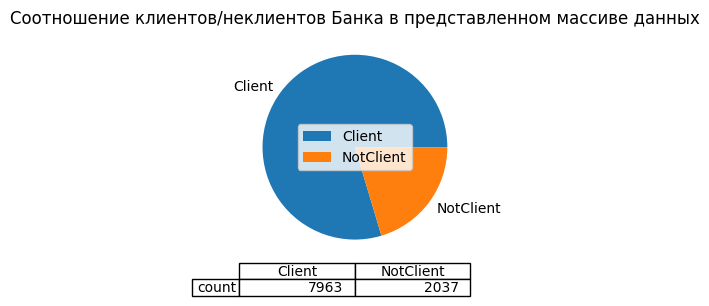

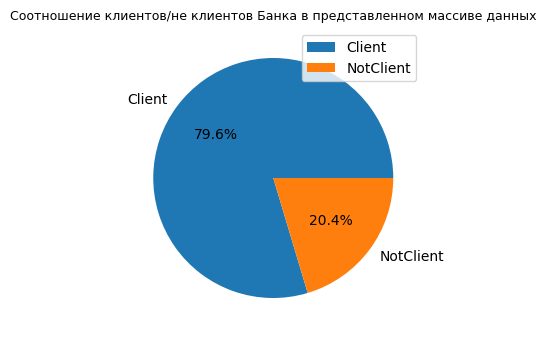

In [144]:
import pandas as pd 
import matplotlib.pyplot as plt
churn_data = pd.read_csv('churn/churn.csv')
churn_data_copy = churn_data.copy() # делаем копию таблицы в целях безопасности 

# введем отдельный признак, клиент не клиент согласно статусу лояльности Exited — статус лояльности (1 — ушедший клиент, 0 — лояльный клиент)
churn_data_copy['ClientOrNot']=churn_data_copy['Exited'].astype('category') 

# теперь пробежимся по стобцу с 1 и 0 и привратим этот в клиент, не клиент. 
churn_data_copy['ClientOrNot'] = churn_data_copy['ClientOrNot'].apply(lambda x:'Client' if x == 0 in churn_data_copy['ClientOrNot'] else 'NotClient')
# строим круговую диаграмму, чтобы понять как соотносится количество клиентов и не клиентво банка. 
churn_data_9_1=churn_data_copy['ClientOrNot'].value_counts()

# в количественном составе 
churn_data_9_1.plot(kind='pie',
                    figsize=(3,3),
                    title = 'Соотношение клиентов/неклиентов Банка в представленном массиве данных',
                    table = True,
                    legend=True, 
                    layout=True)


fig = plt.figure(figsize=(3,3))
axes = fig.add_axes([0, 0, 1, 1])
axes.pie(
    churn_data_9_1,
    labels=churn_data_9_1.index,
    autopct='%.1f%%')
axes.legend() 
axes.set_title('Соотношение клиентов/не клиентов Банка в представленном массиве данных', fontsize = 9)
churn_data_copy_2 = churn_data_copy.copy()

Выводы по заданию 9.1: как мы видем по графику, как в абсолютных значениях, так и в относительных %, количество лояльных клиентов банка практически 80%. Всего лишь 20% клиентов с небольшим ушедшие. Выводы пока рано делать. 


*****

9.2. Постройте график, показывающий распределение баланса пользователей, у которых на счету больше 2 500 долларов. Опишите распределение и сделайте выводы.

Text(0.5, 1.0, 'Распределение баланса счетов в тыс.долларов по количеству клиентов банка')

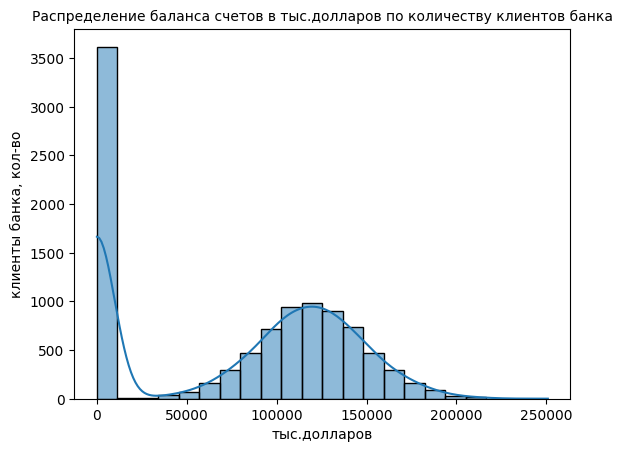

In [71]:
# для решения задачи строим простую гистограмму, чтобы понять распределение клиентов по величине состояния баланса 
import seaborn as sns 
import matplotlib.pyplot as plt

balance_plot = sns.histplot(data=churn_data, x = 'Balance', kde = True)
balance_plot.set_xlabel('тыс.долларов')
balance_plot.set_ylabel('клиенты банка, кол-во')
balance_plot.set_title('Распределение баланса счетов в тыс.долларов по количеству клиентов банка',fontsize = 10)

Выводы по заданию 9.2: как видно из диаграммы, доминирующие число клиентов банка имеет баланс около 10 тыс.долларов и таких порядка 35%, остальные 65% клиентов имеют баланс от 50 тыс до 250 тыс.долларов.  

***

9.3. Посмотрите на распределение баланса клиента в разрезе признака оттока. Как различаются суммы на накопительном счёте ушедших и лояльных клиентов? Подумайте и напишите, с чем это может быть связано, что может не устраивать ушедших клиентов в банке.

Text(0.5, 1.0, 'Баланс денег на счетах у клиетов банка')

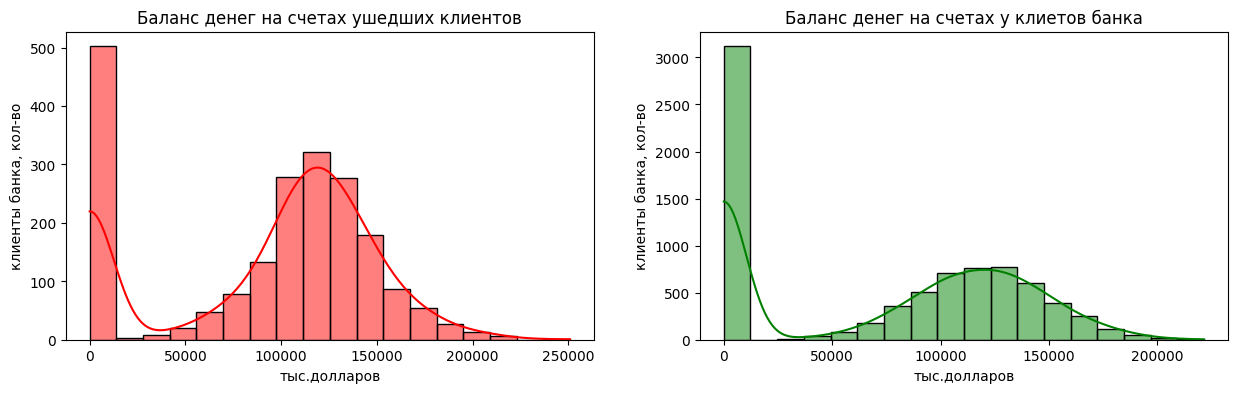

In [72]:
import seaborn as sns 
import matplotlib.pyplot as plt

# по сути для решения задачи мне нужно два графика, по аналогии с предыдущей гистограммой, которая хорошо показывает количествую
# историю по сравнению категорий. единственное, построим их рядом. 

# сделаем маски нужные на наш датафрейм 
group_9_3_1 = churn_data_copy[churn_data_copy['Exited']==1]
group_9_3_2 = churn_data_copy[churn_data_copy['Exited']==0]

# сделаем холст с двумя рядом графиками 
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))

# добавим туда два графика по маскам 
sns.histplot(data=group_9_3_1, x = 'Balance', color='red', kde = True, ax=axes[0])
sns.histplot(data=group_9_3_2, x = 'Balance',color='green', kde = True, ax=axes[1])
# немного обозначений на холст и графики 
axes[0].set_xlabel('тыс.долларов')
axes[1].set_xlabel('тыс.долларов')
axes[1].set_ylabel('клиенты банка, кол-во')
axes[0].set_ylabel('клиенты банка, кол-во')
axes[0].set_title('Баланс денег на счетах ушедших клиентов')
axes[1].set_title('Баланс денег на счетах у клиетов банка')

Выводы по заданию 9.3: из графиков видим. 

1. Высокий уровень клиентов, у которых баланс со счетом до 10 тыс.доларов. 3 тыс. случаев. против тех, кто ушел из банка, лишь 500 (неклиентов в 6 раз меньше, чем клиентов). 

2. По остальным величинам состояния счетов клиентов банка , в два раза больше чем число ушедших клиентов. 

Среди ушедших клиентов есть клиенты с балансом более 200 тыс.долларов. Повод задуматься. 

***

9.4. Посмотрите на распределение возраста в разрезе признака оттока. В какой группе больше потенциальных выбросов? На какую возрастную категорию клиентов стоит обратить внимание банку?

<Axes: xlabel='Age', ylabel='ClientOrNot'>

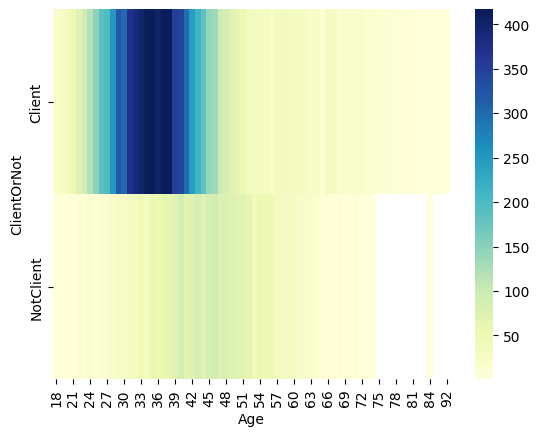

In [73]:
# Для решения данной задачи, наиболее информативно будет построить тепловую диаграмму
# в разрезе двух признаков, это клиент/не клиент и по возрасту, увидим сразу в какой возрастной группе 
# идет максимальный отток. 
import seaborn as sns 
import matplotlib.pyplot as plt
# делаем сводную таблицу, куда закидываем нужные поля агрегации по которым надо собираться 
table_9_4_1 = churn_data_copy.pivot_table(values='Balance', index='ClientOrNot',columns='Age', aggfunc='count')
# строим тепловую диаграмму 
sns.heatmap(data=table_9_4_1, cmap ='YlGnBu')


Выводы по заданию 9.4: из графика видим, что по оттоку клиентов все более или менее размазано в возрастной группе от 30 до 57. Чуть чаще случается в возрастных группах 39, 43, 46 лет. 

***


9.5. Постройте график, который показывает взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты. Добавьте расцветку по признаку оттока клиентов. Какова взаимосвязь между признаками? Если не видите явной взаимосвязи, укажите это.

Text(0.5, 1.0, 'Зависимость рейтинга от предполагаемой за клиента и не клиента банка')

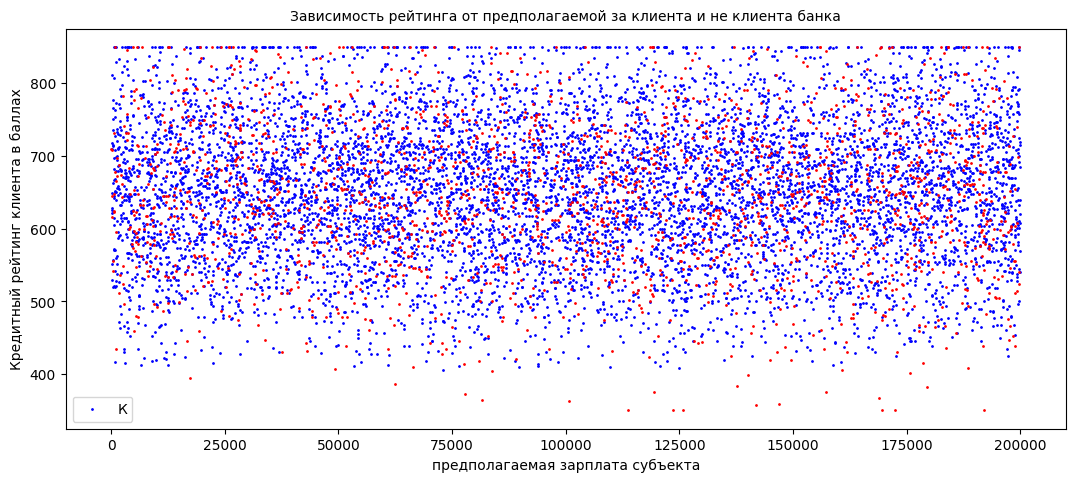

In [74]:
# особо мудрить не будем, сразу сделаем две маски, которые позволяют разделять пул данных клиента и не клиента 
# выбрал обычный график рассеивания 
mask_9_5_1 = churn_data_copy[churn_data_copy['ClientOrNot']=='Client']
mask_9_5_2 = churn_data_copy[churn_data_copy['ClientOrNot']=='NotClient']

# строим полотно и добавляем оси, где будем размещать графическое изображения данных 
fig = plt.figure(figsize=(10, 4))
axes = fig.add_axes([0, 0, 1, 1])
# первый график рассеивания на котором зависимость рейтинга с зарплатой Клиента. 
axes.scatter(
    x=mask_9_5_1['EstimatedSalary'], 
    y=mask_9_5_1['CreditScore'], 
    s=1,
    marker='o',
    c = 'blue' )
axes.legend('Клиент')
# второй график рассеивания на котором зависимость рейтинга с зарплатой Не клиента. 
axes.scatter(
    x=mask_9_5_2['EstimatedSalary'], 
    y=mask_9_5_2['CreditScore'], 
    s=1,
    marker='o',
    c = 'red', )
# немного информации на оси и название графика. 
axes.set_xlabel('предполагаемая зарплата субъекта')
axes.set_ylabel('Кредитный рейтинг клиента в баллах')
axes.set_title('Зависимость рейтинга от предполагаемой за клиента и не клиента банка', fontsize = 10)

Выводы по заданию 9.5: как видим из графика, 
1. Еще раз наглядно по красным точкам видно, что неклиентов существенно меньше чем клиентов. 
2. с учетом того, что сочетание рейтинга и зарплаты равномерно распределено по графику. т.е. количество клиентов/неклиентов с равными зарплатами и разным рейтингом по графику равномерное. Нет всплесков и очагов, где например видно, что в каком-то именно рейтинге, или в какой-то именно зарплате наблюдается большое количество клиентов/неклиентов. 
К сожалению, в данном сопряжении таких признаков, как кредитный рейтинг и заработная плата клиента/неклиента - ценной аналитики и выводов получить не удалось. 


*****

9.6. Кто чаще уходит, мужчины или женщины? Постройте график, который иллюстрирует это.

Text(0.5, 1.0, 'Распределение по гендерому признаку ушедших клиентов')

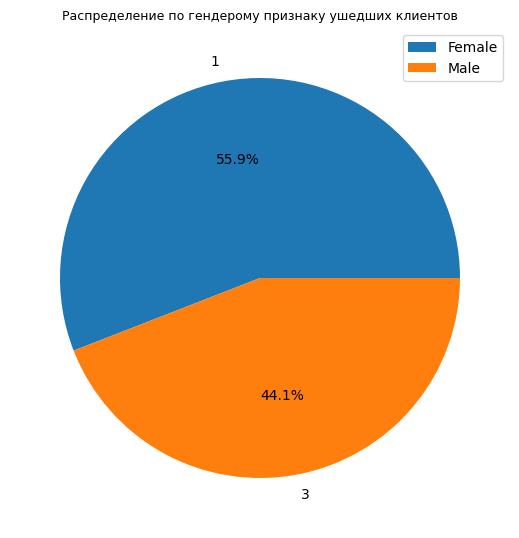

In [ ]:
# делаем группировку по полям гендер и клиент не клиент, добавляем количество и сбрасываем индексы 
female_male = churn_data_copy.groupby(['Gender','ClientOrNot']).size().reset_index(name='Count')
# накладываем маску, и выбираем только ушедших 
female_male = female_male[female_male['ClientOrNot']=='NotClient']
# добавляем расчетное поле процент, и считаем его 
female_male['Percent'] = female_male['Count']/female_male['Count'].sum()*100

# строим график круговой и по ушедшим 
fig_9_6= plt.figure(figsize=(5, 5))
axes = fig_9_6.add_axes([0, 0, 1, 1])
axes.pie(female_male['Percent'],labels=female_male['Gender'].index,autopct='%.1f%%')
axes.legend(female_male['Gender']) 
axes.set_title('Распределение по гендерому признаку ушедших клиентов', fontsize = 9) 


***

9.7. Как отток клиентов зависит от числа приобретённых у банка услуг? Для ответа на этот вопрос постройте многоуровневую столбчатую диаграмму.

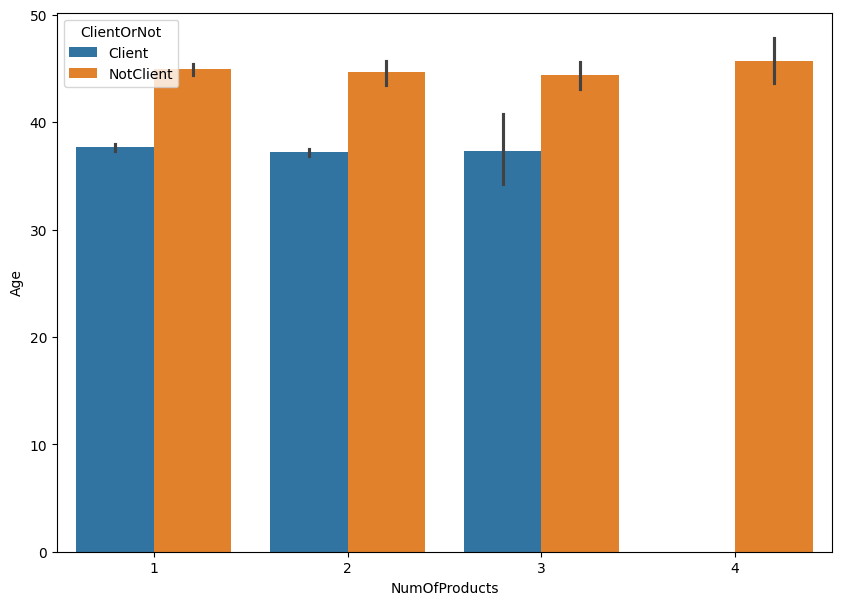

In [125]:
# строим многоуровневую диаграмму, в принципе у нас можно никак не обрабатывать массив данных, 
# возьмем два фактора - возраст и количество продуктов. и построи это в отношении категории клиент, не клиент. 

import matplotlib.pyplot as plt
fig_9_7 = plt.figure(figsize=(10,7))
barplot_9_7_1= sns.barplot(data = churn_data_copy, x='NumOfProducts',y='Age', hue='ClientOrNot')

Вывод по заданию 9.7: мое мнение такое. какой то сильной зависимости количества продуктов на отток клиентов установить не удается. мы видим, что у тех кто уходит было и 1 и 2 и 3 продукта. Единственное, вопросы вызывает ушедшие клиенты у которых четыре продукта, тут надо продолжать почему так получается. Скорее всего, банк делает дополнительные усилия и пытается продать четвертый продукт, чтобы как то получить лояльность клииента. 
Вопросы вызывает, то что не одного клиента нет с четырмя продуктами. 

*****

9.8. Как влияет наличие статуса активного клиента на отток клиентов? Постройте диаграмму, иллюстрирующую это. Что бы вы предложили банку, чтобы уменьшить отток клиентов среди неактивных?

<Axes: xlabel='NumOfProducts-Gender-Age', ylabel='ClientOrNot-IsActiveMember'>

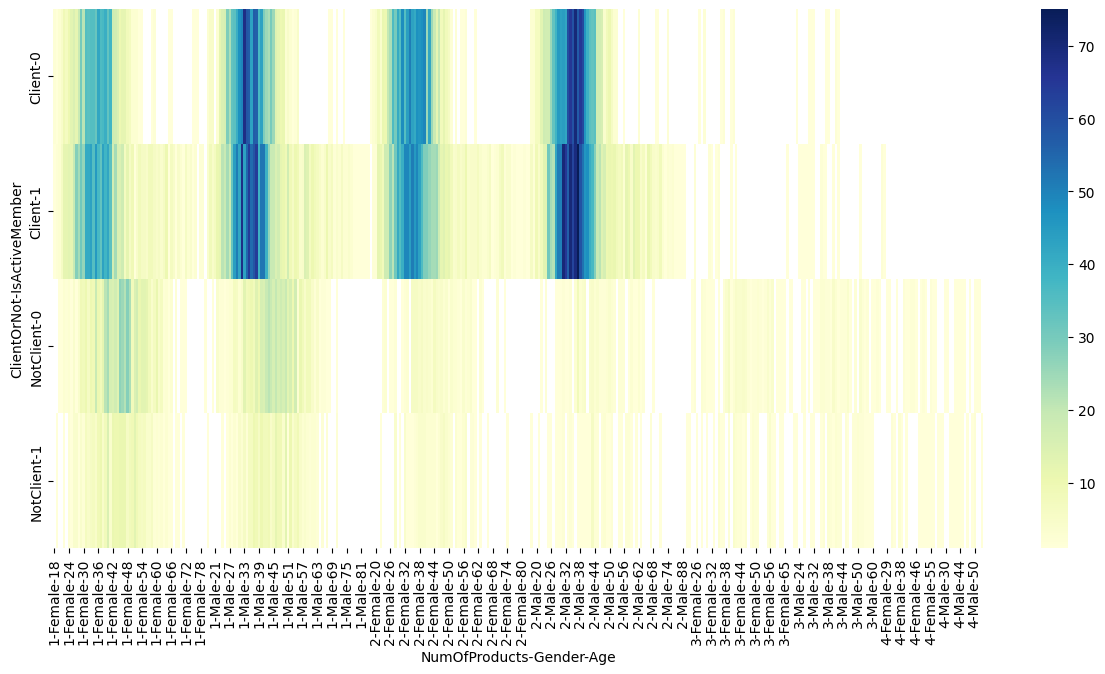

In [126]:
import matplotlib.pyplot as plt
# я решил сразу сделать график в разрезе множиства категорий, чтобы выводы максимально были приземленные. 
# по оси абцисс у нас две категори возраст и гендер 
# по оси ординат мы стром разбивку клиент/неклиент и разбивку по активности и неактивностик клиента. 
# Client 1 клиент и активный, Client0 - клиент и не активный,  NotClient1 - неклиент но активный. NotClient0 - неклиент и не активный 
table_9_8_1 = churn_data_copy.pivot_table(values='RowNumber', index=['ClientOrNot','IsActiveMember'],columns=['NumOfProducts','Gender','Age'], aggfunc='count')
# строим тепловую диаграмму 
fig_9_8 = plt.figure(figsize=(15,7))
sns.heatmap(data=table_9_8_1, cmap ='YlGnBu')
#display(table_9_8_1)

Выводы по заданию 9.8: 
В моем понимании отток это динамический показатель, т.е. величина, разница,  когда мы сравниваем прошлый отчет с текущим и смотрим на одинаковые сущности/драйверы. Сейчас у нас кейс больше похож на статичную картину. 
У нас есть неклиенты, среди которых есть активная часть. Как понимать данную сущность? ну, то есть они не клиенты, но при этом клиенты? :))) Ну, вот например. Есть не клиент, он не активный, у него есть счет на несколько сот тыс баксов, и есть карта. Внимание вопрос, почему он определен как НЕ клиент? Странная история, конечно! :) 
В итоге, на вопрос задания - как статус активного клиента влияет на отток, я ответить не могу. потому что активные есть среди как клиентов (это понятно), так есть и неактивные среди неклиентов (это мне вообще не понятно). 

****

9.9. В какой стране доля ушедших клиентов больше? Постройте тепловую картограмму, которая покажет это соотношение на карте мира. Предположите, с чем это может быть связано.

In [128]:
import plotly
import plotly.express as px
# откидываем тех кто клиенты через маску. 
mask_9_9_1 = churn_data_copy[churn_data_copy['ClientOrNot']=='NotClient']

# группируем по стране, обнуляем индекс и добавляем поле количество. 
country_counts = (mask_9_9_1.groupby('Geography').size().reset_index(name='Count'))

# строим график 

fig_9_9= px.choropleth(
    data_frame=country_counts,
    locations = 'Geography',
    locationmode = 'country names',
    range_color=[0,3000], 
    color='Count',
    title='Распределение по миру ушедших клиентов банка', 
    
    width=800, 
    height=500, 
    color_continuous_scale='Reds'
)
fig_9_9.show()

C:\Users\rus-l\AppData\Local\Temp\ipykernel_22260\2413961758.py:11: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig_9_9= px.choropleth(


Вывод по заданию 9.9: ответ во Франции доля ушедших клиентов больше. 

***

9.10. Переведите числовой признак CreditScore в категориальный. Для этого воспользуйтесь функцией get_credit_score_cat(), которая приведена ниже. Примените её к столбцу CreditScore и создайте новый признак CreditScoreCat — категории кредитного рейтинга.

Постройте сводную таблицу, строками которой являются категории кредитного рейтинга (CreditScoreCat), а столбцами — количество лет, в течение которых клиент пользуется услугами банка (Tenure). В ячейках сводной таблицы должно находиться среднее по признаку оттока (Exited) — доля ушедших пользователей.

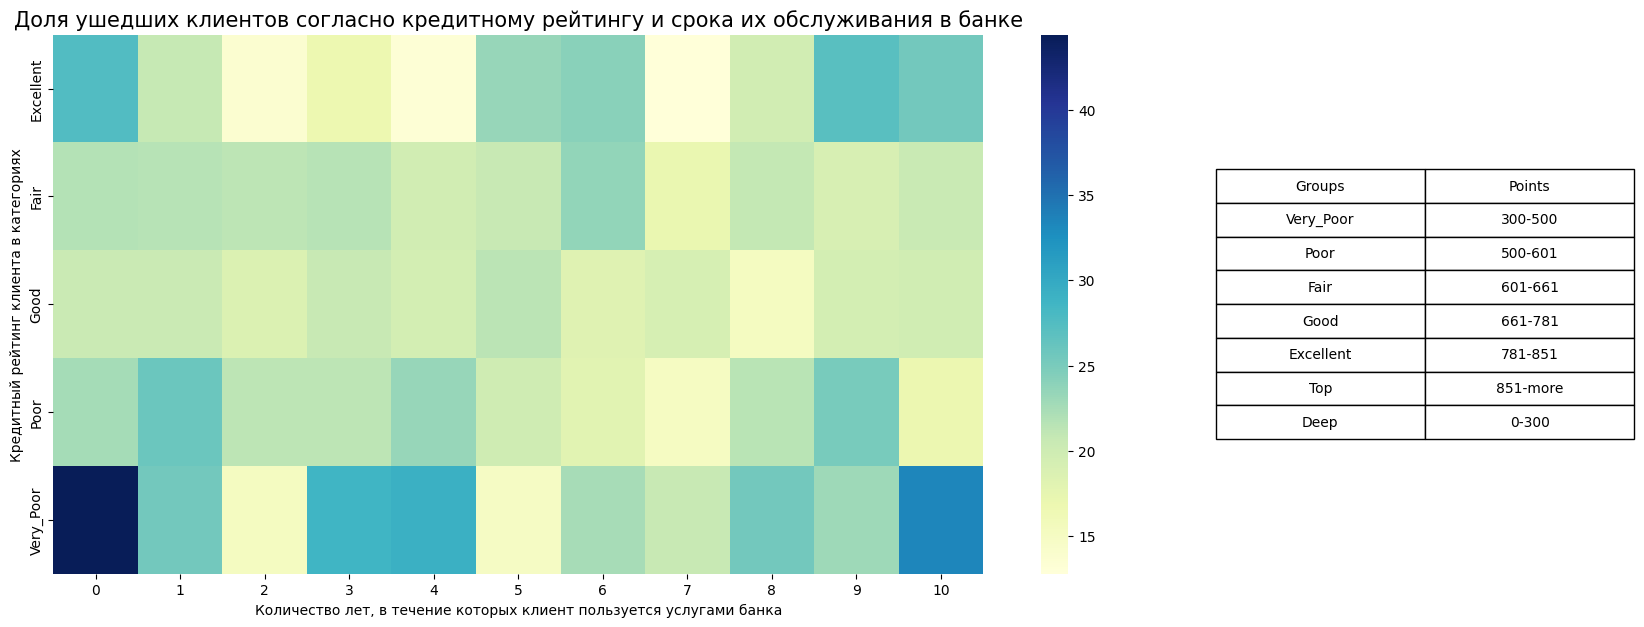

In [ ]:
# переносим функцию которую дали в премере (хотя думаю надо было бы ученикам дать ее самостоятельно написать)
def get_credit_score_cat(credit_score):
    if credit_score >= 300 and credit_score < 500:
        return "Very_Poor"
    elif credit_score >= 500 and credit_score < 601:
        return "Poor"
    elif credit_score >= 601 and credit_score < 661:
        return "Fair"
    elif credit_score >= 661 and credit_score < 781:
        return "Good"
    elif credit_score >= 781 and credit_score < 851:
        return "Excellent"
    elif credit_score >= 851:
        return "Top"
    elif credit_score < 300:
        return "Deep"
    
# добавляем новое поле категории кредитного рейтинга и закидываем туда результат примменения функции к колонке с числовым рейтингом клиентов 
churn_data_copy_2['CreditScoreCat'] = churn_data_copy_2['CreditScore'].apply(get_credit_score_cat)
# делаем сводную таблицу и находим среднее по ушедшим т.е. получается если мы берем среднее по единицам из всей выборки 
# это и получается доля, дополнительно умножаем и отсекаем чифры после запятой. 
table_9_10_2= (churn_data_copy_2.pivot_table(values='Exited', 
                                            index='CreditScoreCat',
                                            columns='Tenure', aggfunc='mean')*100).round(1)

# строрим тепловую диаграмму, добавляем детали по осям и названию. 
fig_9_10 = plt.figure(figsize=(15, 7))

heatmap_9_10 = sns.heatmap(data=table_9_10_2, cmap ='YlGnBu')
heatmap_9_10.set_xlabel('Количество лет, в течение которых клиент пользуется услугами банка')
heatmap_9_10.set_ylabel('Кредитный рейтинг клиента в категориях')
heatmap_9_10.set_title('Доля ушедших клиентов согласно кредитному рейтингу и срока их обслуживания в банке', fontsize = 15)

# решил добавить легенду по очкам рейтингов клиентов. 
table_legend = pd.DataFrame(data={'Groups':['Very_Poor','Poor','Fair','Good','Excellent','Top','Deep'],
                                  'Points':['300-500', '500-601','601-661','661-781','781-851','851-more','0-300']})
# теперь таблицу добавляем на график. пришлось посмотреть у ИИ как это лучше сделать с точки зрения сигнатуры, так как 
# мы этот материал не проходили :) 

plt.table(
    cellText=table_legend.values,
    colLabels=table_legend.columns,
    cellLoc='center',
    loc='right',
    bbox=[1.25, 0.25, 0.45, 0.5]
)


Вывод по 9.10: Топ -3 оттока клиентов с рейтингами и сроками обслуживания: 
1. Very poor  - 0 лет 
2. Very poor  - 10 лет 
3. Very poor  - 4 лет 
